# Demo Notebook for Melting Point Prediction using the Molten Salt Calculator

In this notebook we demonstrate how the MoltenSaltCalculator can be used to predict the melting point of a salt. We use NaCl as an example and show the results of simulations liquid-solid phase coexistence at three different temperatures. Note that this is a rather involved simulation and it takes a few hours on a GPU to run. The molecular dynamics simulations are run using the [SuperSalt](https://www.nature.com/articles/s41467-025-62450-1) MLIP model, which can be downloaded from [Zenodo](https://zenodo.org/records/15734798).

## Initialization

First we load the imports, define the system parameters and load the MLIP model.

In [1]:
import random
from pathlib import Path

import myplots as p
import numpy as np
from ase import units
from ase.build import bulk
from ase.io import Trajectory
from tqdm import tqdm

import moltensaltcalc as msc

p.use_style()

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# System size
REPEAT_Z = 15
REPEAT_XY = 4
N_ATOMS = 8 * REPEAT_Z * REPEAT_XY**2  # 1920
# Initial density
INIT_DENSITY = 1.5  # g/cm^3

# Liquid temperature where the liquid structure is attained
T_LIQUID = 1600  # K
# Target melting point temperatures where the long NPH simulations are performed
T_LIST = [800, 1000]  # K

# Number of simulation steps (1 fs/step)
STEPS_INIT = 10000  # fs
STEPS_HEAT = 10000  # fs
STEPS_COOL = 10000  # fs
STEPS_NPH = 100000  # fs

# Size of the vacuum region between the liquid and the solid when combining
MARGIN_DISTANCE_COMBINE = 2.0  # A

# Initialize model
CWD = Path.cwd()
OUTDIR = CWD / "mp_trajs"
sim = msc.MoltenSaltSimulator(
    "mace", model_parameters={"model_path": CWD / "SuperSalt-swa.model"}, dispersion=None
)  # TODO

## Simulation

Next, for each temperature the system is initialized from a cubic rocksalt structure. After a 10 ps NPT equilibration at the target temperature, the system is divided into a liquid and a solid phase. The liquid phase is heated to 1600 K for 10 ps (NPT) to ensure that it assumes the liquid (disordered) phase and cooled back to the target temperature for another 10 ps (NPT). Afterwards, the two phases are combined with a 2 A vacuum layer in between and the system is allowed to equilibrate in a 100 ps NPH simulation.

In [ ]:
for T in T_LIST:
    print(
        f"\n=================================================================\nRunning NPT simulations with {N_ATOMS} atoms and {T} K and saving to {OUTDIR}.\n=================================================================\n"
    )
    out_dir = OUTDIR / str(N_ATOMS) / str(T)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Filenames for the trajectories
    pre_eq_supersalt = out_dir / "00_pre_supersalt_all.traj"
    pre_eq_mh0 = out_dir / "01_pre_mh0_all.traj"
    heat_file = out_dir / "10_heat.traj"
    cool_file = out_dir / "20_cool.traj"
    full_system_nph = out_dir / "50_full_coexistence_nph.traj"

    # Build the system from the rocksalt structure, with a cell with side length ratios 1:1:5
    NaCl = bulk("NaCl", "rocksalt", a=1.0, cubic=True)
    NaCl = NaCl.repeat((REPEAT_XY, REPEAT_XY, REPEAT_Z))
    # Rescale the lattice to match the density guess
    mass = sum(NaCl.get_masses())  # amu
    density_guess_au = INIT_DENSITY * 1e3 * units.kg / units.m**3  # amu/Å³
    volume_guess = mass / density_guess_au  # Å³
    # All three sides are scaled the same way, so the volume scales with s^3
    scale = (volume_guess / NaCl.get_volume()) ** (1 / 3)

    # 1. Pre-equilibrate the whole system at the target melting temperature
    NaCl.calc = sim.calc
    sim.run_npt_simulation(NaCl, T, logfile=None, traj_file=pre_eq_supersalt, steps=STEPS_INIT, print_status=False)

    # Separate the top and bottom parts
    NaCl.wrap()
    positions = NaCl.positions.copy()
    mid_z = (max(x[2] for x in positions) + min(x[2] for x in positions)) / 2
    solid_indices = []
    liquid_indices = []
    for i, z in enumerate(positions[:, 2]):
        if z < mid_z:
            solid_indices.append(i)
        else:
            liquid_indices.append(i)
    solid_part = NaCl[solid_indices]
    liquid_part = NaCl[liquid_indices]
    # Set half the cell size for each of the parts
    reduced_cell = np.array(NaCl.get_cell().copy())
    reduced_cell[2, 2] -= mid_z
    reduced_cell[2, 2] += MARGIN_DISTANCE_COMBINE
    for part in [solid_part, liquid_part]:
        part.set_cell(reduced_cell)
        part.center(axis=2)

    # 2. Melt the top part
    liquid_part.calc = sim.calc
    sim.run_npt_simulation(
        liquid_part,
        T_LIQUID,
        npt_dyn="nptberendsen_inhomogeneous",
        steps=STEPS_HEAT,
        mask=(0, 0, 1),
        logfile=None,
        traj_file=heat_file,
        print_status=False,
    )

    # 3. Cool the top part to the target melting temperature
    liquid_part.calc = sim.calc
    sim.run_npt_simulation(
        liquid_part,
        T,
        npt_dyn="nptberendsen_inhomogeneous",
        steps=STEPS_COOL,
        mask=(0, 0, 1),
        logfile=None,
        traj_file=cool_file,
        print_status=False,
    )

    # Combine the two phases again, on top of each other
    liquid_part.wrap()
    solid_part.wrap()
    cell = np.array(solid_part.get_cell())
    cell[2, 2] += MARGIN_DISTANCE_COMBINE
    solid_part.set_cell(cell)
    cell[2, 2] += np.array(liquid_part.get_cell())[2, 2] + MARGIN_DISTANCE_COMBINE
    liquid_part.positions[:, 2] += np.array(solid_part.get_cell())[2, 2]
    full_system = solid_part + liquid_part
    full_system.set_cell(cell)

    # 4. Simulate the full system at the target melting temperature (NPH)
    full_system.calc = sim.calc
    sim.run_npt_simulation(
        full_system,
        T,
        taut_fs=None,
        npt_dyn="melchionna",
        steps=STEPS_NPH,
        logfile=None,
        traj_file=full_system_nph,
        print_status=False,
    )

## Analysis of the Melting Point

After the trajectories have been obtained, we can determine the melting point of the system. For this, we investigate the evolution of the phases at the different target temperatures:

1. At T = 800 K, we can see that the solid phase grows, thus the melting point is higher than 800 K.
2. At T = 1000 K, we can see that the solid phase shrinks, thus the melting point is lower than 1000 K.

This lets us conclude that the predicted melting point is between 800 and 1000 K, which is not all too different from the experimental value of 1070 K.

  0%|          | 0/101 [00:00<?, ?it/s]

100%|██████████| 101/101 [00:00<00:00, 912.85it/s]


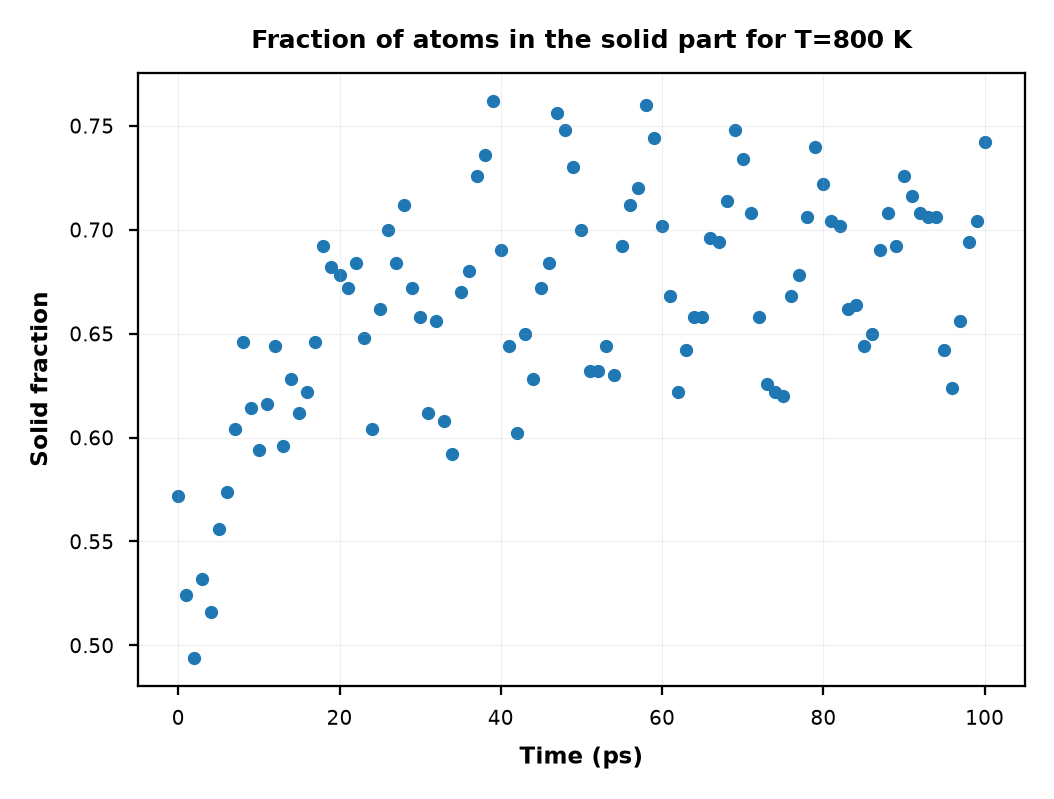

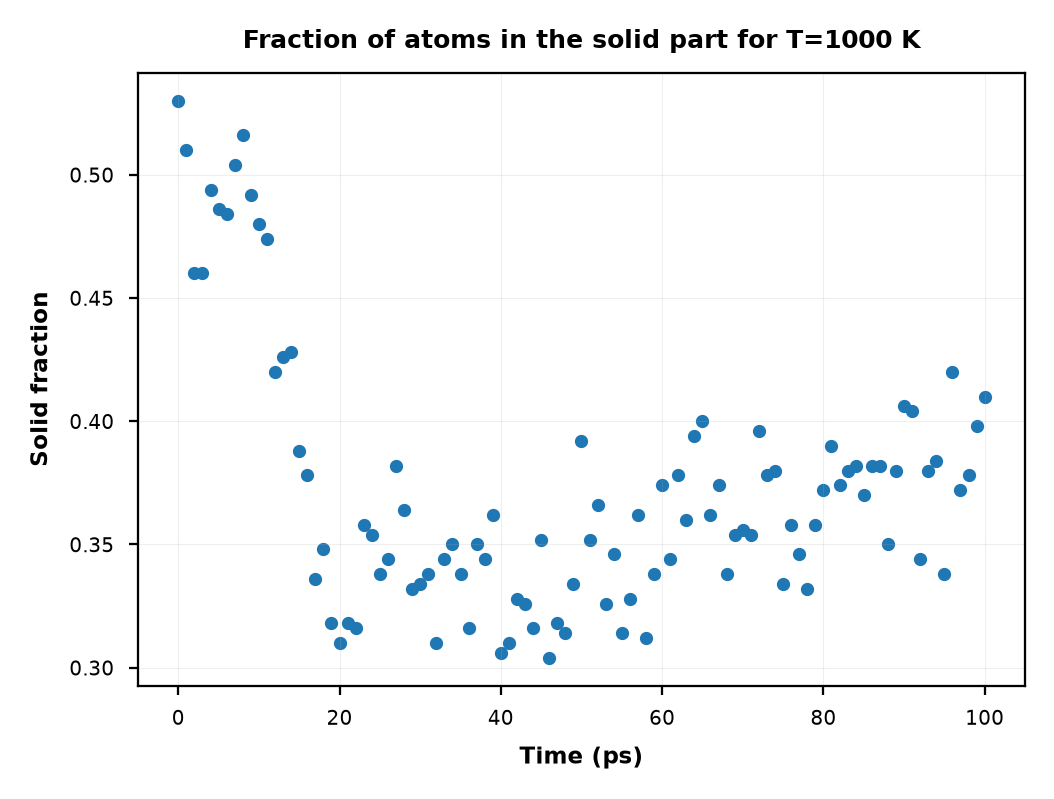

In [2]:
THRESHOLD = 0.5
NBINS = 500
EVERY_NTH = 100

for T in T_LIST:
    DATA_DIR = (
        Path.cwd() / ".." / ".." / "10_uMLIPs_for_MS_properties" / "mp_prod_fixed" / "1920" / str(T)
    )  # TODO: FIXME
    traj = Trajectory(DATA_DIR / "50_full_coexistence_nph.traj")
    subsampled_traj = traj[::EVERY_NTH]
    solid_fraction = np.zeros(len(subsampled_traj))
    for i, frame in enumerate(tqdm(subsampled_traj)):
        z = frame.get_positions()[:, 2]
        hist, _ = np.histogram(
            z,
            bins=NBINS,
            range=(0, max(z)),
        )
        density = hist / hist.mean()
        order = np.abs(density - density.mean())
        solid_fraction[i] = np.mean(order > THRESHOLD)

    fig, ax = p.new()
    p.scatter(ax, np.arange(len(subsampled_traj)) * EVERY_NTH / 100, solid_fraction)
    p.label(ax, "Time (ps)", "Solid fraction", f"Fraction of atoms in the solid part for T={T:.0f} K")

The growth of the phases is determined by the number of atoms at distinct locations along the z-axis (linear density). When the linear density oscillates periodically, the part of the phase is considered to be solid, when it's roughly constant, it's considered to be liquid. For illustration, we show histograms of the linear density at the different temperatures below for snapshots at representative times (0, 10, 25 and 50 ps):

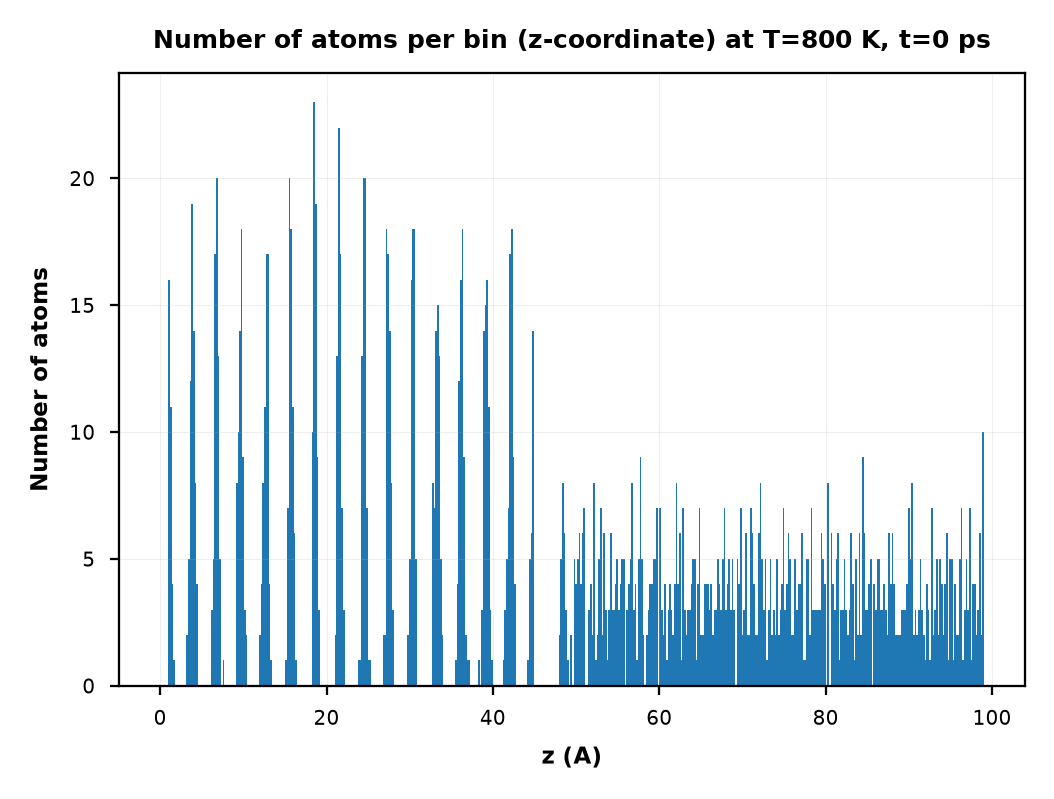

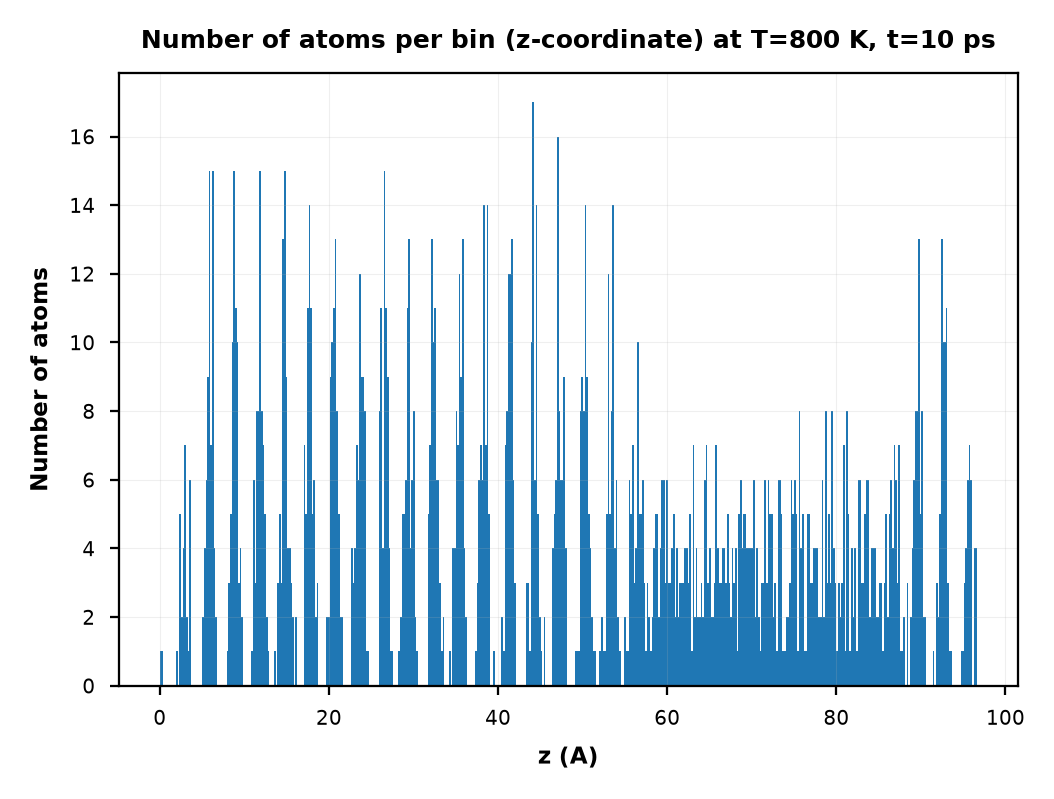

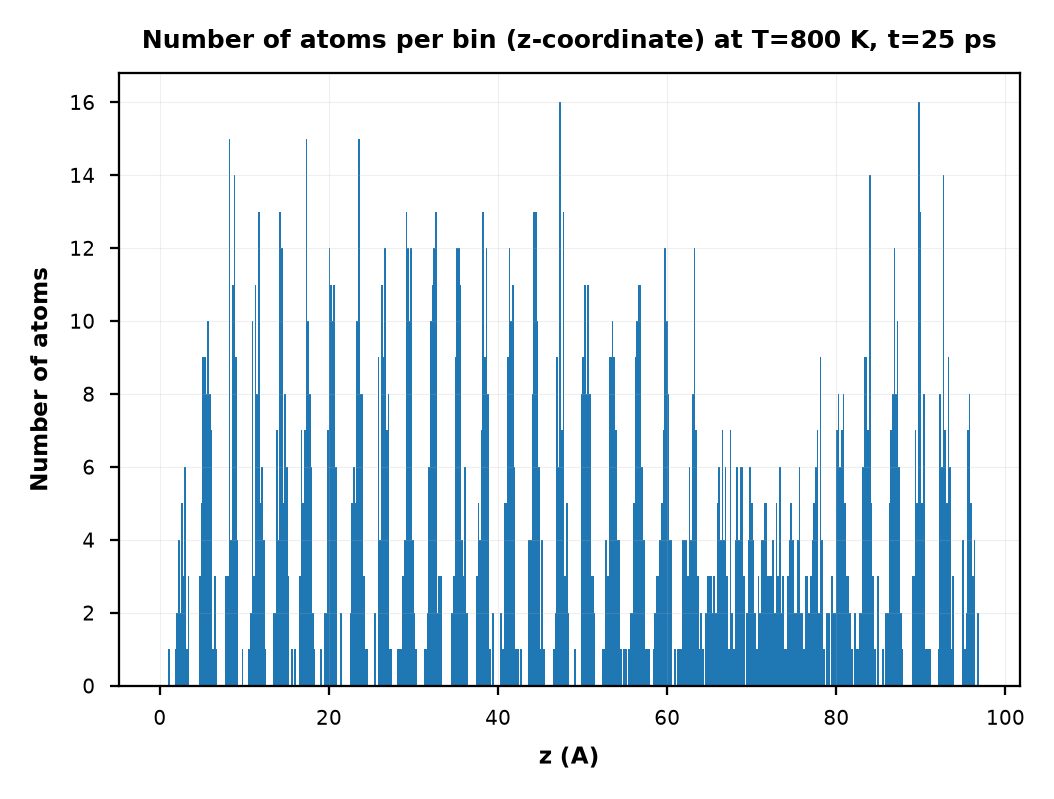

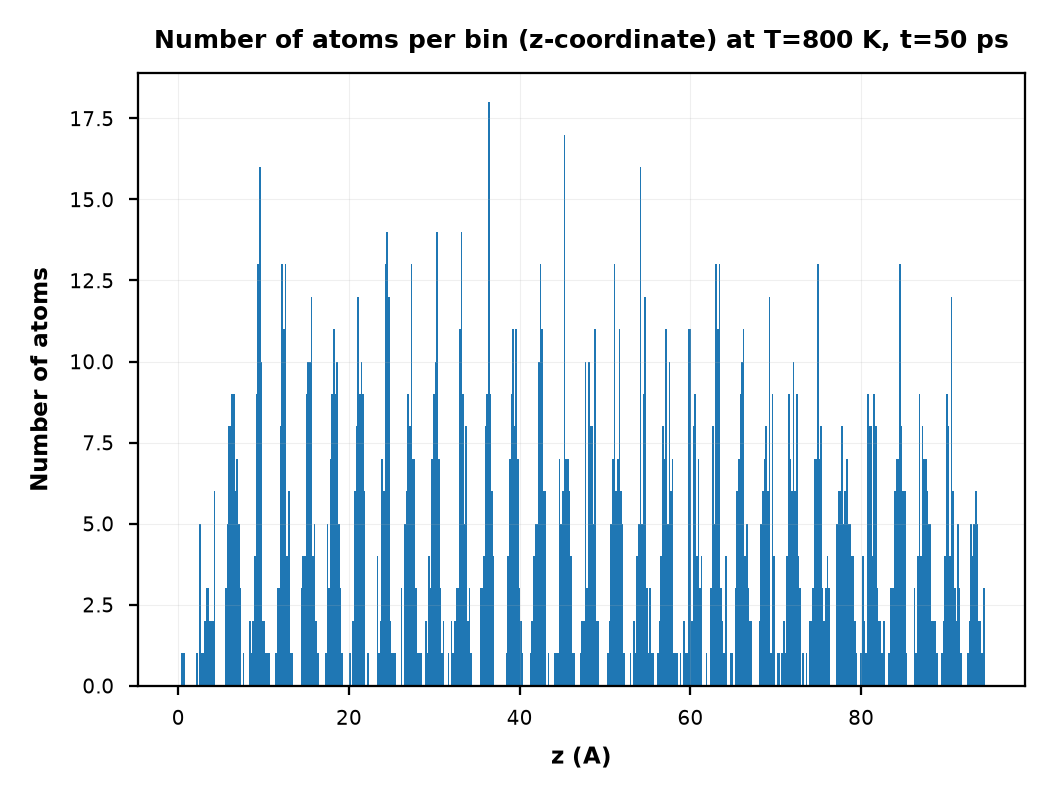

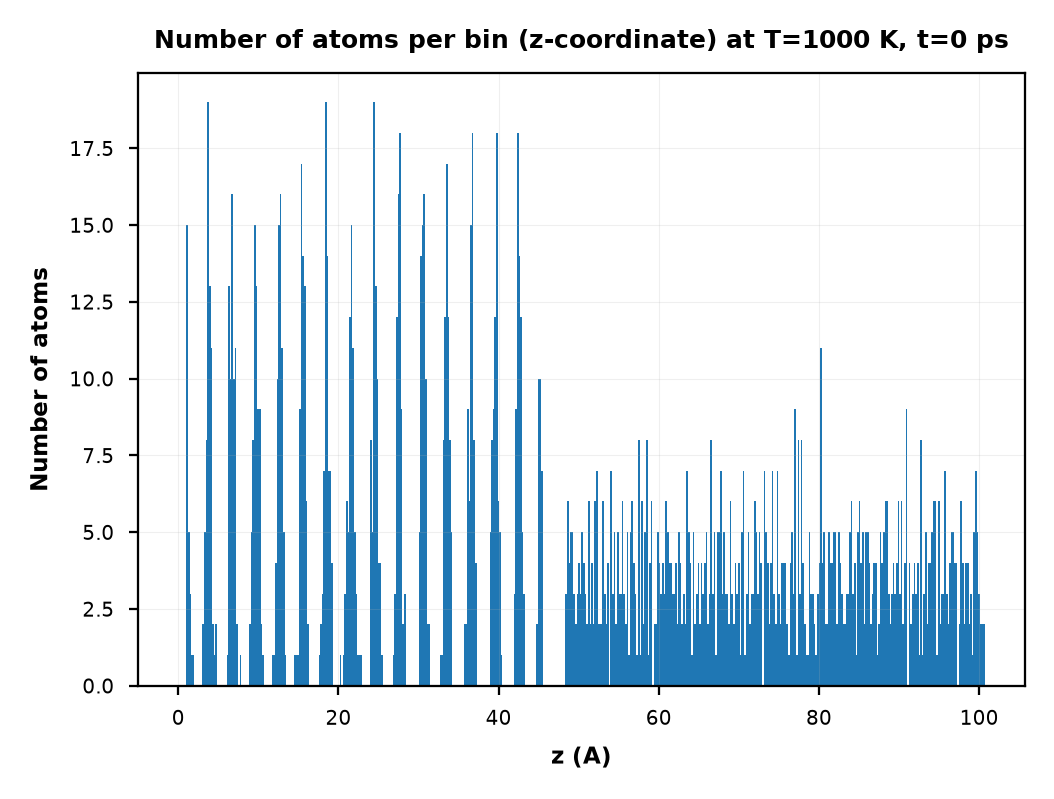

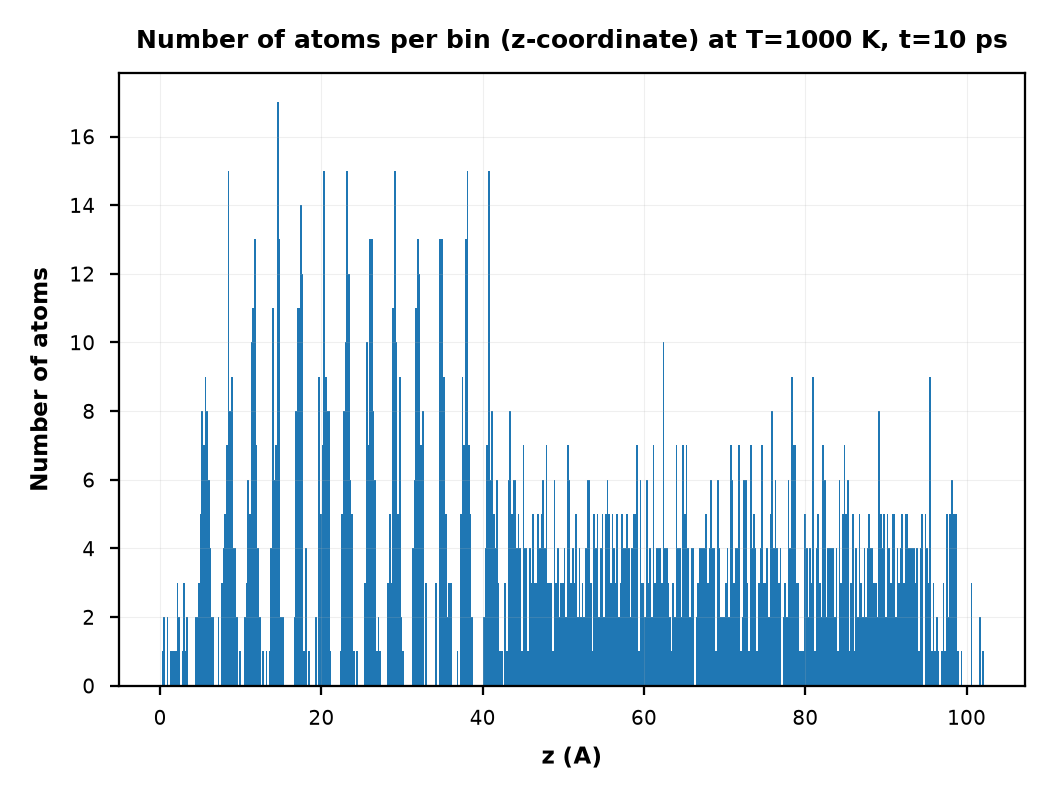

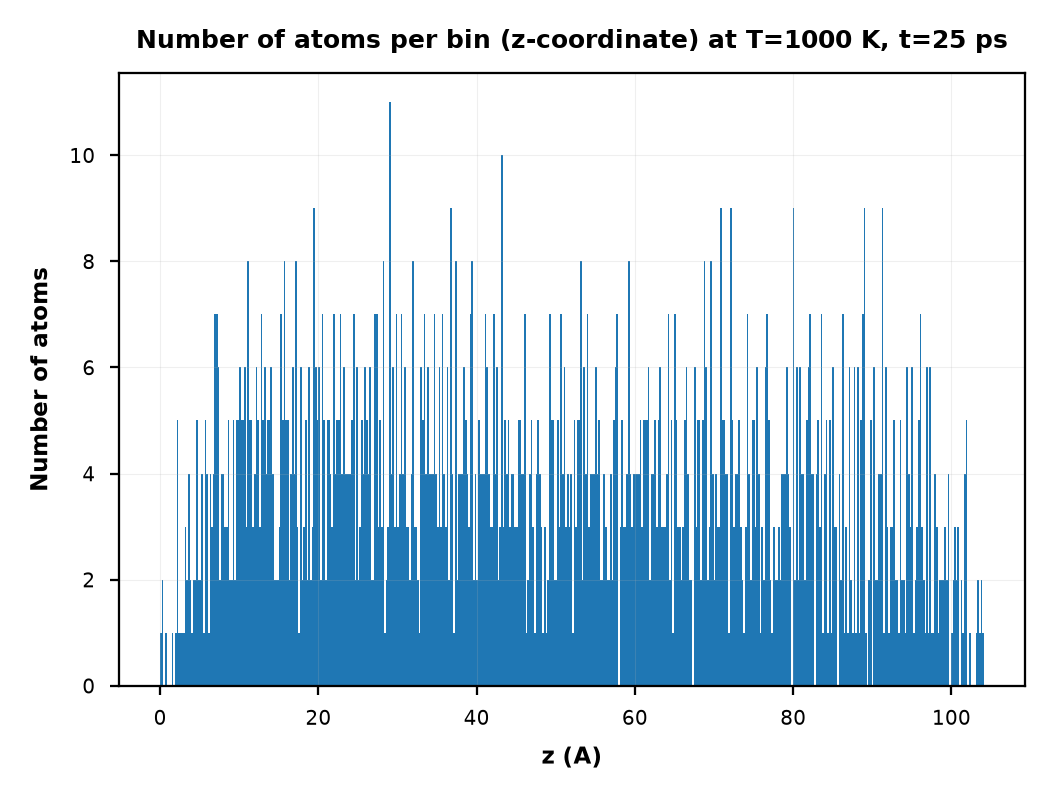

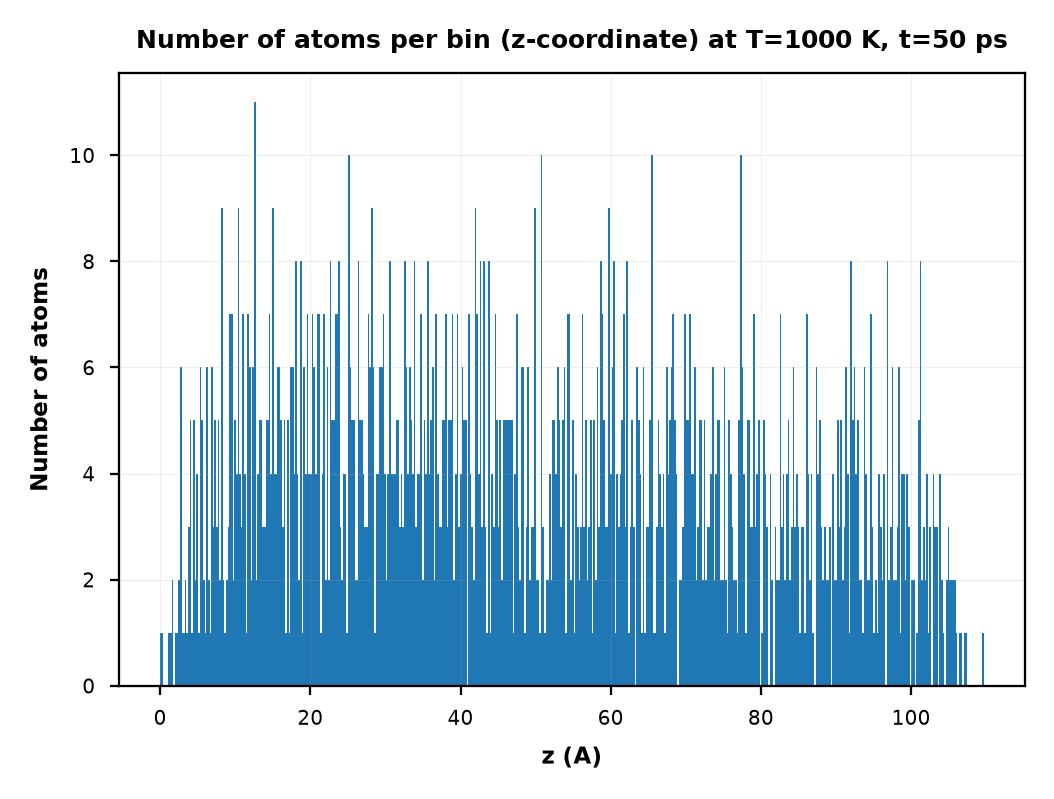

In [3]:
EXAMPLE_FRAMES = [0, 1000, 2500, 5000]
for T in T_LIST:
    DATA_DIR = (
        Path.cwd() / ".." / ".." / "10_uMLIPs_for_MS_properties" / "mp_prod_fixed" / "1920" / str(T)
    )  # TODO: Fixme
    traj = Trajectory(DATA_DIR / "50_full_coexistence_nph.traj")
    for frame in EXAMPLE_FRAMES:
        z = traj[frame].positions[:, 2]
        fig, ax = p.new()
        ax.hist(z, bins=NBINS, range=(0, np.max(z)))
        p.label(
            ax,
            "z (A)",
            "Number of atoms",
            f"Number of atoms per bin (z-coordinate) at T={T:.0f} K, t={frame / 100:.0f} ps",
        )